# LeetCode #89: Gray Code

https://leetcode.com/problems/gray-code/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(2^n \cdot n)$ | $O(2^n)$ |
| **Binary-Reflected XOR Formula** ★ | $O(2^n)$ | $O(2^n)$ |

---

## Understanding the Methods

### Brute Force
Use BFS or backtracking to build each next Gray code by flipping one bit from the previous code, checking that the result hasn't been seen before. Each candidate check can cost $O(n)$ per bit flip attempt across $O(n)$ bits, making it $O(2^n \cdot n)$ overall.

### Optimal: Binary-Reflected XOR Formula ★
For index $i$ in $[0, 2^n)$, the Gray code is simply $i \oplus (i >> 1)$. This closed-form exploits the binary-reflected Gray code property: adjacent indices differ in exactly one bit and the XOR formula generates them in $O(1)$ per element.

**Why this is better than Brute Force:** No search or visited-set is needed — each value is computed directly from its index in $O(1)$, reducing the total work from $O(2^n \cdot n)$ to $O(2^n)$.

**Constraints:**
* `1 <= n <= 16`

## Solutions

### C#

In [ ]:
public IList<int> GrayCode(int n) {
    var result = new List<int>();
    // Iterate over all 2^n indices and apply the XOR formula
    for (int i = 0; i < (1 << n); i++) {
        // XOR with right-shift gives the binary-reflected Gray code
        result.Add(i ^ (i >> 1));
    }
    return result;
}

### Python

In [ ]:
def grayCode(self, n: int) -> list[int]:
    # Apply the XOR formula for each index in [0, 2^n)
    return [i ^ (i >> 1) for i in range(1 << n)]

### Go

In [ ]:
func grayCode(n int) []int {
    result := make([]int, 1<<n)
    // Directly compute each Gray code as index XOR (index >> 1)
    for i := range result {
        result[i] = i ^ (i >> 1)
    }
    return result
}

### Rust

In [ ]:
pub fn gray_code(n: i32) -> Vec<i32> {
    // Map each index to its Gray code via the XOR formula
    (0..(1 << n)).map(|i| i ^ (i >> 1)).collect()
}

## Example Scenarios

**1. Common Case**
**Input:** n = 2
Indices 0–3 → 0⊕0=0, 1⊕0=1, 2⊕1=3, 3⊕1=2 → [0,1,3,2]. Adjacent pairs differ by exactly 1 bit: $00→01→11→10$. The sequence wraps too: 10 and 00 differ by one bit.

**2. Slightly Complex**
**Input:** n = 3
Produces 8 codes: [0,1,3,2,6,7,5,4] in binary [$000,001,011,010,110,111,101,100$]. Each consecutive pair has Hamming distance 1, confirming the XOR formula's correctness across 3 bits.

**3. Edge Case: Time Factor**
**Input:** n = 16 (maximum)
Generates $2^{16} = 65{,}536$ codes. Time is $O(2^{16})$; no search overhead means this runs in milliseconds. Brute force with a visited set would be noticeably slower.

**4. Edge Case: Space Factor**
**Input:** n = 1
Only two elements [0, 1]. Minimum case; the result list holds exactly $2^1 = 2$ integers. $O(2^n)$ space is unavoidable since the output itself requires it.

**5. Almost-Impossible but Plausible**
**Input:** n = 15
Output has $2^{15} = 32{,}768$ entries. The last entry ($32{,}767 \oplus 16{,}383 = 16{,}384$) wraps back and differs from the first (0) in exactly 1 bit, satisfying the circular Gray code property even at near-maximum scale.

### Infographic

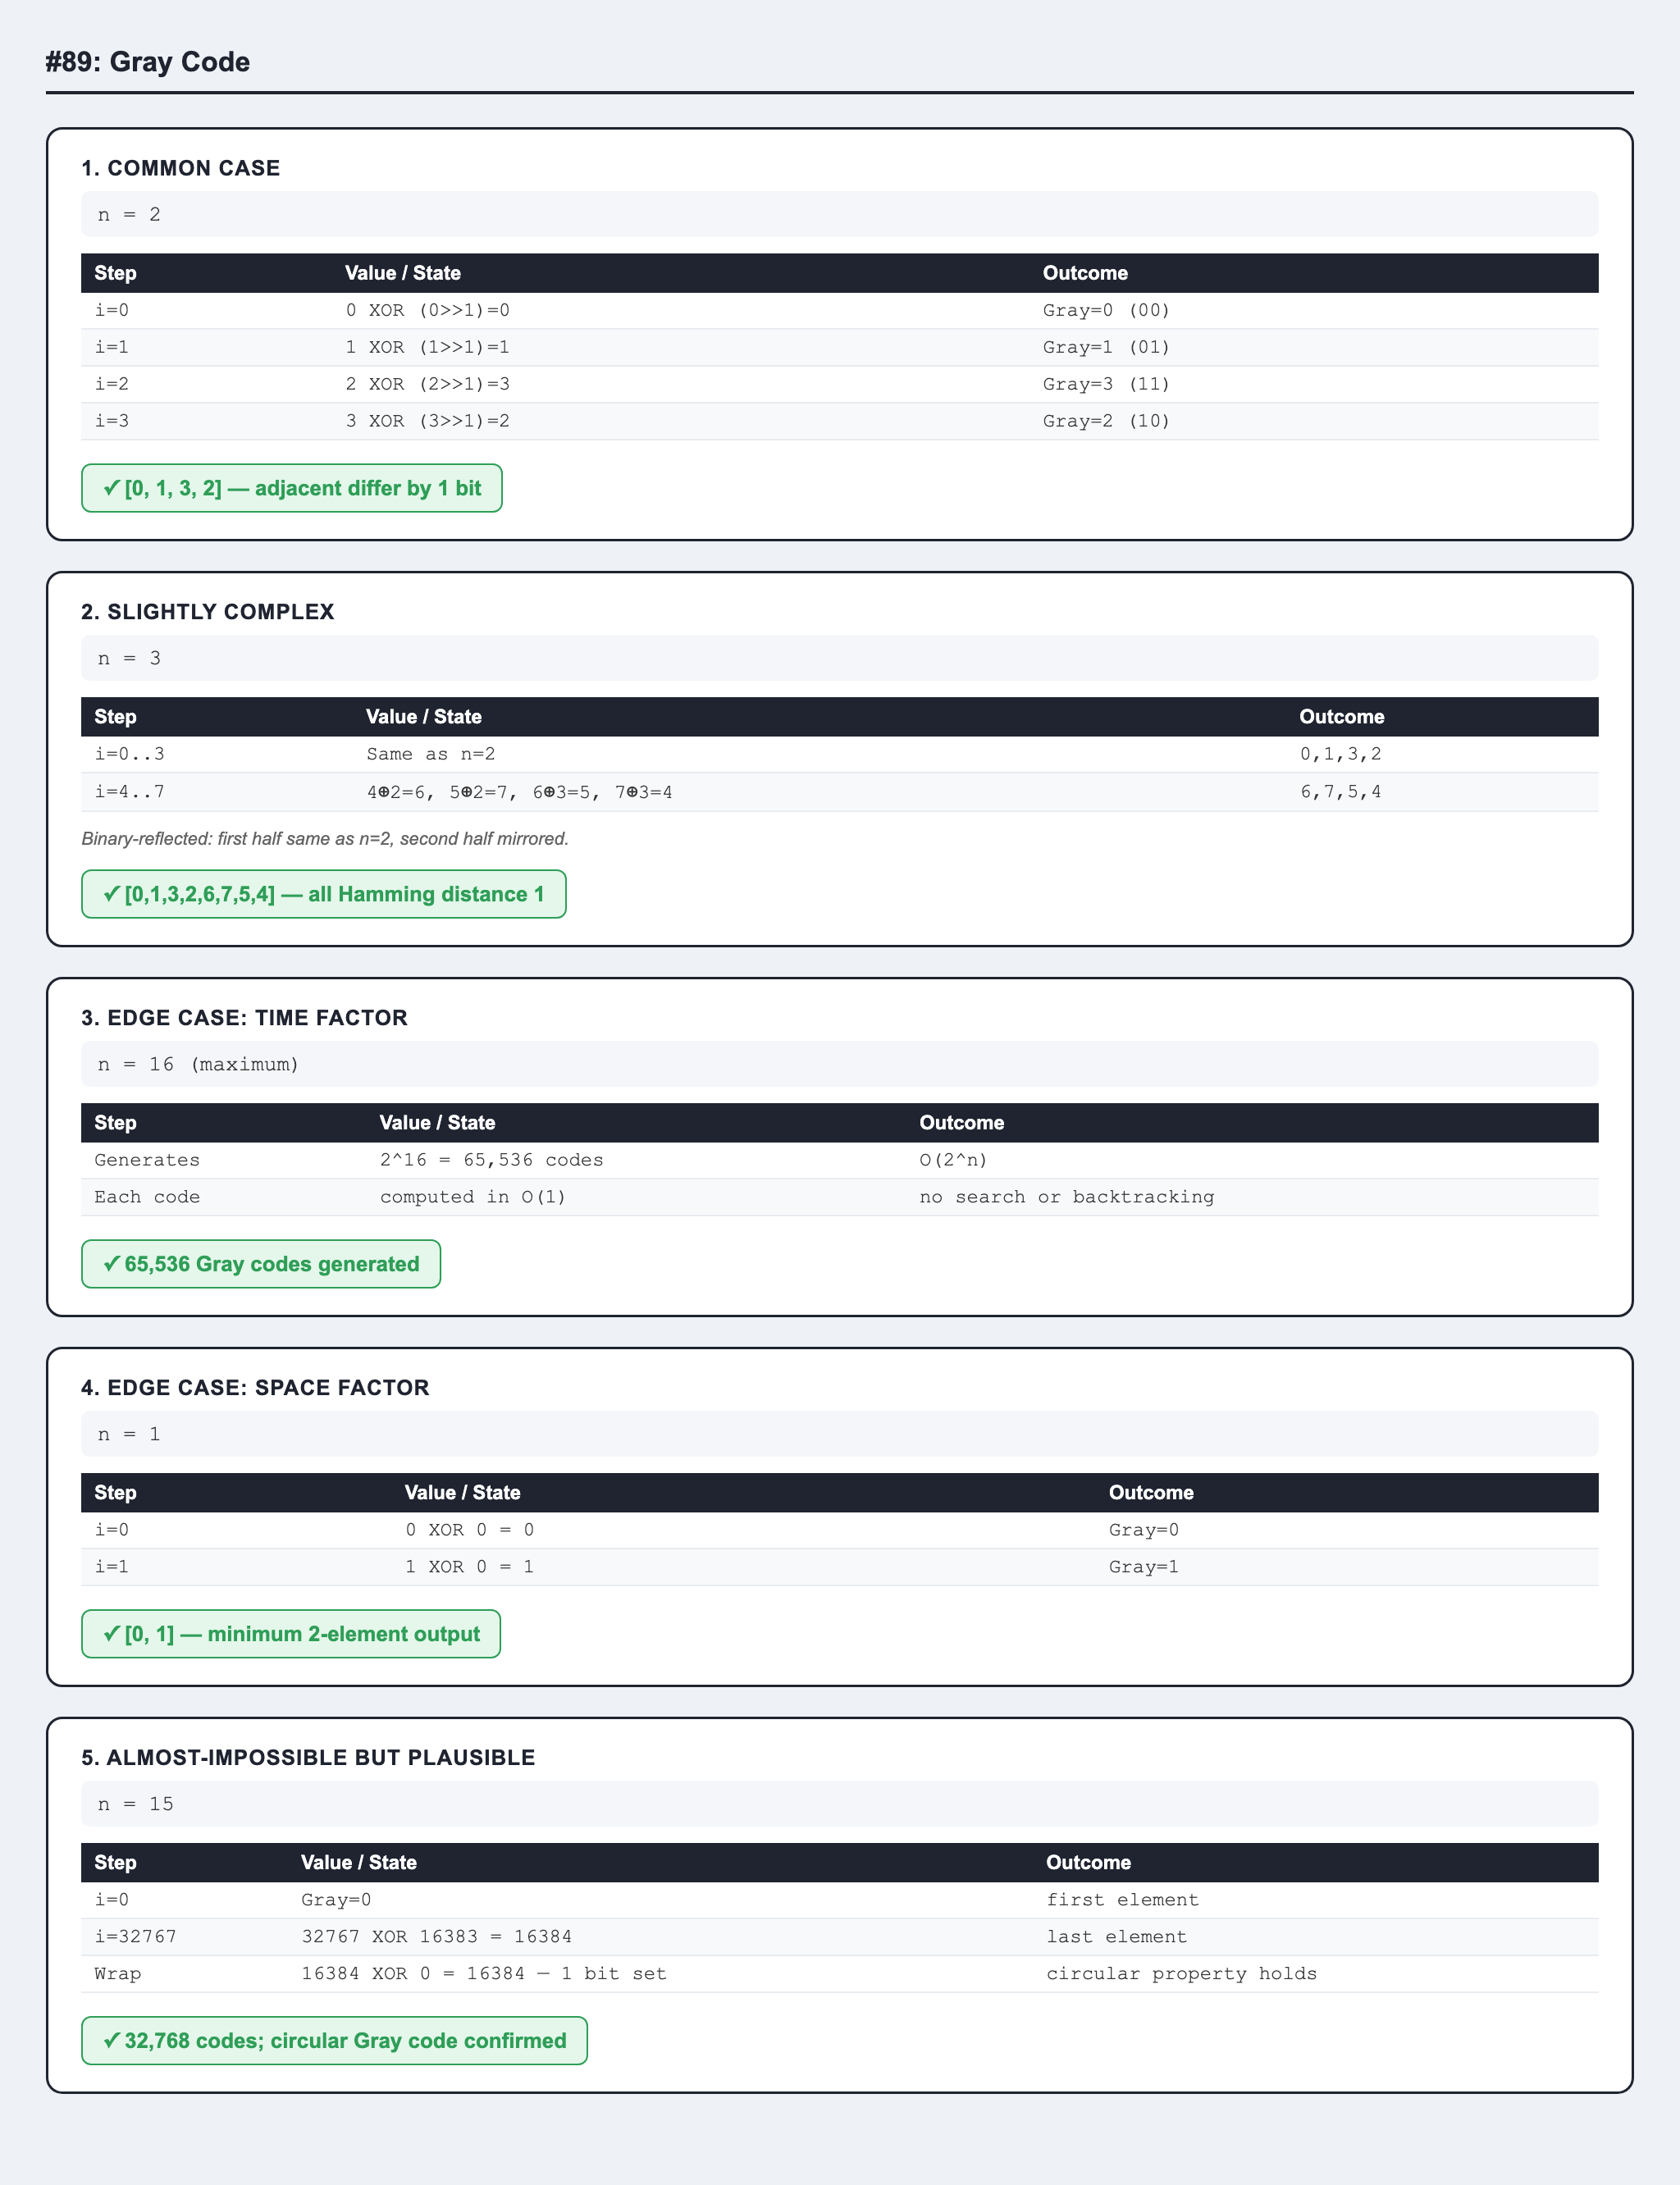